In [1]:
epochs = 20
lr=1e-5


In [2]:
!pip install torch torchvision matplotlib pydicom
import zipfile, pydicom, io, numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.5 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, zipfile
# Copy to Colab local for speed
if not os.path.exists('/content/DCM.zip'):
    !cp "/content/drive/MyDrive/PIS/DCM.zip" "/content/DCM.zip"

zip_path = '/content/DCM.zip'
z = zipfile.ZipFile(zip_path)

img_slice_paths = [f for f in z.namelist()
                   if f.startswith('DCM/Task1/ImagesTr/') and f.lower().endswith('.dcm')]

folders = sorted(set(f.split('/')[3] for f in img_slice_paths))
print(f'Folders found: {folders[:10]}... Total: {len(folders)}')


img_files, lbl_files = [], []
for folder in folders:
    imgs = [f for f in img_slice_paths if f.startswith(f'DCM/Task1/ImagesTr/{folder}/IMG')]
    lbls = [f for f in z.namelist() if f.startswith(f'DCM/Task1/LabelsTr/{folder}/IMG')]
    img_dict = {os.path.basename(f): f for f in imgs}
    lbl_dict = {os.path.basename(f): f for f in lbls}
    for fname in img_dict:
        if fname in lbl_dict:
            img_files.append(img_dict[fname])
            lbl_files.append(lbl_dict[fname])

print(f'Total paired slices: {len(img_files)}')
print('Sample image:', img_files[:3])
print('Sample mask :', lbl_files[:3])


Mounted at /content/drive
Folders found: ['10000', '10001', '10002', '10006', '10007', '10011', '10012', '10014', '10015', '10016']... Total: 92
Total paired slices: 6816
Sample image: ['DCM/Task1/ImagesTr/10000/IMG0001.dcm', 'DCM/Task1/ImagesTr/10000/IMG0002.dcm', 'DCM/Task1/ImagesTr/10000/IMG0003.dcm']
Sample mask : ['DCM/Task1/LabelsTr/10000/IMG0001.dcm', 'DCM/Task1/LabelsTr/10000/IMG0002.dcm', 'DCM/Task1/LabelsTr/10000/IMG0003.dcm']


In [4]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
    img_files, lbl_files, test_size=0.2, random_state=42
)

print(f'Train: {len(train_imgs)}, Val: {len(val_imgs)}')

Train: 5452, Val: 1364


In [5]:
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import zipfile

class ZipDicomSliceDataset(Dataset):
    def __init__(self, zip_path, img_files, lbl_files, target_size=(256,256)):
        self.zip_path = zip_path
        self.img_files = img_files
        self.lbl_files = lbl_files
        self.target_size = target_size
        self.to_tensor = transforms.ToTensor()
        self.resize = transforms.Resize(self.target_size, interpolation=Image.NEAREST)
        self.z = zipfile.ZipFile(zip_path)
    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_bytes = self.z.read(self.img_files[idx])
        mask_bytes = self.z.read(self.lbl_files[idx])

        img_dcm = pydicom.dcmread(io.BytesIO(img_bytes))
        mask_dcm = pydicom.dcmread(io.BytesIO(mask_bytes))

        image = img_dcm.pixel_array.astype(np.float32)
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)

        mask_arr = mask_dcm.pixel_array.astype(np.float32)
        mask_bin = ((mask_arr == 1.0) | (mask_arr == 2.0)).astype(np.float32)

        image = self.resize(Image.fromarray((image * 255).astype(np.uint8)))
        mask = self.resize(Image.fromarray((mask_bin * 255).astype(np.uint8)))

        image = self.to_tensor(image)
        mask = self.to_tensor(mask)
        mask = (mask > 0.5).float()

        # Diagnostic print for the first few samples
        if idx < 3:
            print(f"Sample {idx}: image shape {image.shape}, mask unique {mask.unique().tolist()}")

        return image, mask

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    ZipDicomSliceDataset(zip_path, train_imgs, train_lbls),
    batch_size=16, shuffle=True, num_workers=1, drop_last=False
)
val_loader = DataLoader(
    ZipDicomSliceDataset(zip_path, val_imgs, val_lbls),
    batch_size=16, shuffle=False, num_workers=1, drop_last=False
)

# Check first batch shape
imgs, masks = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}, {masks.shape}")


print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Train batches per epoch:", len(train_loader))
print("Val batches per epoch:", len(val_loader))

Batch shape: torch.Size([16, 1, 256, 256]), torch.Size([16, 1, 256, 256])
Train samples: 5452
Val samples: 1364
Train batches per epoch: 341
Val batches per epoch: 86


In [7]:
import torch
import torch.nn as nn
import math


class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


def get_2d_sincos_pos_embed(embed_dim, grid_h, grid_w, device=None, dtype=torch.float32):
    """
    Create 2D sine-cosine positional embeddings (grid) for transformer.
    embed_dim must be even. Splits embedding dim for y and x.
    Returns tensor of shape (grid_h*grid_w, embed_dim)
    """
    if embed_dim % 2 != 0:
        raise ValueError("Embed dim must be even for sincos pos embedding.")
    grid_y = torch.arange(grid_h, dtype=dtype, device=device)
    grid_x = torch.arange(grid_w, dtype=dtype, device=device)
    yy, xx = torch.meshgrid(grid_y, grid_x, indexing='ij')  # (H, W)
    grid = torch.stack([yy, xx], dim=-1).reshape(-1, 2)     # (H*W, 2)

    N = grid.shape[0]
    emb = torch.zeros((N, embed_dim), dtype=dtype, device=device)

    half = embed_dim // 2
    # Create the angle rates for each half
    def angle_rates(dim):
        idx = torch.arange(dim, dtype=dtype, device=device)
        return 1.0 / (10000 ** (2 * (idx // 2) / dim))

    # Y part
    dim_y = half
    rates_y = angle_rates(dim_y)             # (dim_y,)
    angles_y = grid[:, 0:1] * rates_y.unsqueeze(0)  # (N, dim_y)
    emb[:, :dim_y:2] = torch.sin(angles_y[:, ::2])
    emb[:, 1:dim_y:2] = torch.cos(angles_y[:, ::2])

    # X part
    dim_x = half
    rates_x = angle_rates(dim_x)
    angles_x = grid[:, 1:2] * rates_x.unsqueeze(0)
    emb[:, dim_y:dim_y+dim_x:2] = torch.sin(angles_x[:, ::2])
    emb[:, dim_y+1:dim_y+dim_x:2] = torch.cos(angles_x[:, ::2])

    return emb  # (H*W, D)


class AttentionBlock(nn.Module):
    """
    Attention gating as in Attention U-Net.
    g: gating signal (from decoder)
    x: skip connection (from encoder)
    Produces attended x (same shape as x).
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        """
        g: gating signal (decoder feature) shape (B, F_g, H, W)
        x: encoder feature to be attended shape (B, F_l, H, W)
        """
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.psi(g1 + x1)  # (B,1,H,W)
        return x * psi  # broadcast multiply


class TransAttUNetPlusPlus(nn.Module):
    """
    TransAttUNetPlusPlus:
      - Encoder: same as AttentionUNetPlusPlus
      - Bottleneck: DoubleConv -> optional projection -> Transformer encoder
      - Decoder: Attention U-Net++ nested decoder using attended encoder features
    """
    def __init__(self, in_channels=1, out_channels=1, filters=[64,128,256,512,1024],
                 trans_depth=4, trans_heads=8, trans_mlp_ratio=4.0, trans_embed_dim=None, dropout=0.0):
        super().__init__()
        f1, f2, f3, f4, f5 = filters
        self.filters = filters

        # Encoder
        self.enc1 = DoubleConv(in_channels, f1)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(f1, f2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(f2, f3)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(f3, f4)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck conv before transformer
        self.bottleneck_conv = DoubleConv(f4, f5)

        # Transformer embedding dimension (if None, use f5)
        if trans_embed_dim is None:
            self.embed_dim = f5
        else:
            self.embed_dim = trans_embed_dim

        # projection to transformer dim (if different)
        if self.embed_dim == f5:
            self.proj_to_embed = nn.Identity()
            self.proj_back = nn.Identity()
        else:
            # project channel dim f5 -> embed_dim (and back after transformer)
            self.proj_to_embed = nn.Linear(f5, self.embed_dim)
            self.proj_back = nn.Linear(self.embed_dim, f5)

        # Transformer encoder (batch_first True)
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim,
                                                   nhead=trans_heads,
                                                   dim_feedforward=int(self.embed_dim * trans_mlp_ratio),
                                                   dropout=dropout,
                                                   activation='gelu',
                                                   batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=trans_depth)

        # Upsampling (transpose convs) and decoder DoubleConv nodes (UNet++ style)
        self.up4 = nn.ConvTranspose2d(f5, f4, kernel_size=2, stride=2)
        self.up3 = nn.ConvTranspose2d(f4, f3, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose2d(f3, f2, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose2d(f2, f1, kernel_size=2, stride=2)

        # Attention blocks
        self.att4 = AttentionBlock(F_g=f4, F_l=f4, F_int=f4 // 2)
        self.att3 = AttentionBlock(F_g=f3, F_l=f3, F_int=f3 // 2)
        self.att2 = AttentionBlock(F_g=f2, F_l=f2, F_int=f2 // 2)
        self.att1 = AttentionBlock(F_g=f1, F_l=f1, F_int=f1 // 2)

        # Nested decoder convs (UNet++ style). Keep shapes consistent with your earlier implementation.
        self.x3_1 = DoubleConv(f4 + f4, f4)

        self.x2_1 = DoubleConv(f3 + f3, f3)
        self.x2_2 = DoubleConv(f3 * 3, f3)

        self.x1_1 = DoubleConv(f2 + f2, f2)
        self.x1_2 = DoubleConv(f2 * 3, f2)
        self.x1_3 = DoubleConv(f2 * 4, f2)

        self.x0_1 = DoubleConv(f1 + f1, f1)
        self.x0_2 = DoubleConv(f1 * 3, f1)
        self.x0_3 = DoubleConv(f1 * 4, f1)
        self.x0_4 = DoubleConv(f1 * 5, f1)

        # final conv
        self.final = nn.Conv2d(f1, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                 # x0_0   (B, f1, H, W)
        e2 = self.enc2(self.pool1(e1))    # x1_0   (B, f2, H/2, W/2)
        e3 = self.enc3(self.pool2(e2))    # x2_0   (B, f3, H/4, W/4)
        e4 = self.enc4(self.pool3(e3))    # x3_0   (B, f4, H/8, W/8)
        b  = self.bottleneck_conv(self.pool4(e4))  # x4_0  (B, f5, H/16, W/16)

        B, C, H, W = b.shape
        # Flatten spatial dims -> tokens (B, N, C)
        tokens = b.flatten(2).transpose(1, 2)  # (B, N, C) where N = H*W

        # project channels to transformer embed dim if needed
        if isinstance(self.proj_to_embed, nn.Linear):
            tokens = self.proj_to_embed(tokens)  # (B, N, embed_dim)
        else:
            tokens = self.proj_to_embed(tokens)  # Identity

        # positional embedding
        pos_emb = get_2d_sincos_pos_embed(self.embed_dim, H, W, device=tokens.device, dtype=tokens.dtype)  # (N, D)
        pos_emb = pos_emb.unsqueeze(0).expand(B, -1, -1)  # (B, N, D)
        tokens = tokens + pos_emb

        # Transformer encoder
        tokens = self.transformer(tokens)  # (B, N, D)

        # project back to spatial/channel shape
        if isinstance(self.proj_back, nn.Linear):
            tokens = self.proj_back(tokens)  # (B, N, f5)
        else:
            tokens = self.proj_back(tokens)  # Identity

        tokens = tokens.transpose(1, 2).view(B, C, H, W)  # (B, f5, H, W)

        # Now UNet++ nested decoder with attention gating (use same pattern as your attention UNet++)
        up4_b = self.up4(tokens)  # (B, f4, H*2, W*2)
        att_e4 = self.att4(up4_b, e4)
        x3_1 = self.x3_1(torch.cat([up4_b, att_e4], dim=1))  # (B, f4, H*2, W*2)

        up3_x3_1 = self.up3(x3_1)  # (B, f3, H*4, W*4?) careful: sizes match encoder e3
        # note: shapes should align — if your input original H,W are powers of 2 this matches.
        att_e3 = self.att3(up3_x3_1, e3)
        x2_1 = self.x2_1(torch.cat([up3_x3_1, att_e3], dim=1))

        up3_x3_1_again = self.up3(x3_1)
        x2_2 = self.x2_2(torch.cat([e3, x2_1, up3_x3_1_again], dim=1))

        up2_x2_1 = self.up2(x2_1)
        att_e2 = self.att2(up2_x2_1, e2)
        x1_1 = self.x1_1(torch.cat([up2_x2_1, att_e2], dim=1))

        up2_x2_2 = self.up2(x2_2)
        x1_2 = self.x1_2(torch.cat([e2, x1_1, up2_x2_2], dim=1))

        x1_3 = self.x1_3(torch.cat([e2, x1_1, x1_2, up2_x2_2], dim=1))

        up1_x1_1 = self.up1(x1_1)
        att_e1 = self.att1(up1_x1_1, e1)
        x0_1 = self.x0_1(torch.cat([up1_x1_1, att_e1], dim=1))

        up1_x1_2 = self.up1(x1_2)
        x0_2 = self.x0_2(torch.cat([e1, x0_1, up1_x1_2], dim=1))

        up1_x1_3 = self.up1(x1_3)
        x0_3 = self.x0_3(torch.cat([e1, x0_1, x0_2, up1_x1_3], dim=1))

        x0_4 = self.x0_4(torch.cat([e1, x0_1, x0_2, x0_3, up1_x1_3], dim=1))

        out = self.final(x0_4)
        return out

In [8]:
# ---------------- Metric Utilities (Batch-wise) ---------------- #

def _threshold(pred, thr=0.5):
    pred = torch.sigmoid(pred)
    return (pred > thr).float()

def dice_metric(pred, target, eps=1e-6):
    pred = _threshold(pred)
    intersection = (pred * target).sum((1,2,3))
    union = pred.sum((1,2,3)) + target.sum((1,2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()


def accuracy_metric(pred, target, eps=1e-6):
    pred = _threshold(pred)
    correct = (pred == target).float().sum((1,2,3))
    total = torch.tensor(target[0].numel(), device=target.device)
    acc = correct / (total + eps)
    return acc.mean()


def precision_metric(pred, target, eps=1e-6):
    pred = _threshold(pred)
    TP = (pred * target).sum((1,2,3))
    FP = (pred * (1 - target)).sum((1,2,3))
    precision = (TP + eps) / (TP + FP + eps)
    return precision.mean()


def sensitivity_metric(pred, target, eps=1e-6):
    pred = _threshold(pred)
    TP = (pred * target).sum((1,2,3))
    FN = ((1 - pred) * target).sum((1,2,3))
    sensitivity = (TP + eps) / (TP + FN + eps)
    return sensitivity.mean()

def specificity_metric(pred, target, eps=1e-6):
    pred = _threshold(pred)
    TN = ((1 - pred) * (1 - target)).sum((1,2,3))
    FP = (pred * (1 - target)).sum((1,2,3))
    specificity = (TN + eps) / (TN + FP + eps)
    return specificity.mean()


def f1_score_metric(pred, target, eps=1e-6):
    pred = _threshold(pred)
    TP = (pred * target).sum((1,2,3))
    FP = (pred * (1 - target)).sum((1,2,3))
    FN = ((1 - pred) * target).sum((1,2,3))

    precision = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)
    return f1.mean()

class DiceLoss(nn.Module):
    def forward(self, logits, target):
        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        target = target.view(target.size(0), -1)
        inter = (probs * target).sum(1)
        union = probs.sum(1) + target.sum(1)
        dice = (2 * inter + 1e-6) / (union + 1e-6)
        return 1 - dice.mean()

In [9]:
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    ALB_AVAILABLE = True
except:
    ALB_AVAILABLE = False


if ALB_AVAILABLE:
    train_transforms = A.Compose([
        # --- Geometric Augmentations ---
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Affine(scale=(0.9, 1.1), rotate=(-15, 15), translate_percent=(0, 0), p=0.3),

        # --- Intensity Augmentations (for images only) ---
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.4
        ),


        # --- Sharpen / Blur ---
        A.OneOf([
            A.Blur(blur_limit=3),
            A.MedianBlur(blur_limit=3),
            A.MotionBlur(blur_limit=3),
        ], p=0.3),

        # --- Normalize + Convert ---
        A.Normalize(mean=0.0, std=1.0),
        ToTensorV2()
    ])

    val_transforms = A.Compose([
        A.Normalize(mean=0.0, std=1.0),
        ToTensorV2()
    ])

else:
    train_transforms = None
    val_transforms = None


In [10]:
def show_sample_prediction(model, val_loader, epoch):
    model.eval()
    with torch.no_grad():
        imgs, masks = next(iter(val_loader))
        imgs, masks = imgs.to(device), masks.to(device)
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()

    img = imgs[0].cpu().squeeze()
    mask = masks[0].cpu().squeeze()
    pred = preds[0].cpu().squeeze()

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Input"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pred, cmap="gray"); plt.title(f"Pred (Epoch {epoch+1})"); plt.axis("off")
    plt.show()

Using device: cuda
Tesla T4


/tmp/ipython-input-2025208496.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/20:   0%|          | 0/341 [00:00<?, ?it/s]/tmp/ipython-input-2025208496.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20:  16%|█▋        | 56/341 [01:02<05:10,  1.09s/it, loss=1.51]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 1/20:  18%|█▊        | 60/341 [01:07<05:05,  1.09s/it, loss=1.5]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Epoch 1/20:  91%|█████████ | 310/341 [05:49<00:35,  1.15s/it, loss=1.35]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]

Epoch 1/20: Train Loss=1.4291 | Val Loss=1.3739 | Dice=0.4524 | Acc=0.9949 | Prec=0.7977 | Sens=0.6276 | Spec=0.9985 | F1=0.4782 | Time=7.54 min

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


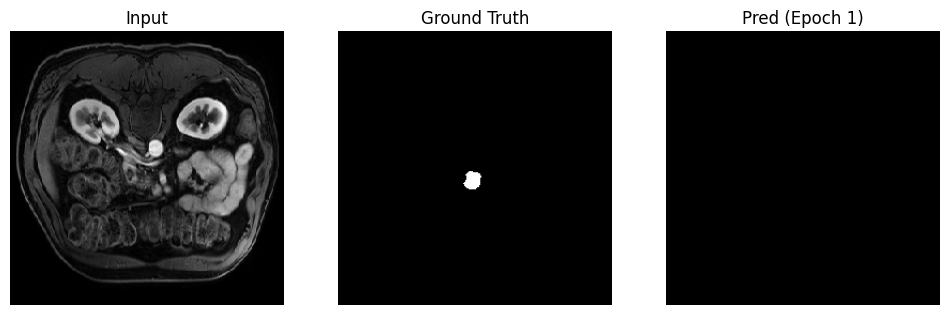

Epoch 2/20:  57%|█████▋    | 195/341 [03:45<02:49,  1.16s/it, loss=1.33]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 2/20:  69%|██████▉   | 236/341 [04:33<02:02,  1.16s/it, loss=1.32]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 2/20:  91%|█████████ | 309/341 [05:57<00:36,  1.16s/it, loss=1.32]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]

Epoch 2/20: Train Loss=1.3337 | Val Loss=1.3211 | Dice=0.4934 | Acc=0.9960 | Prec=0.8570 | Sens=0.6276 | Spec=0.9995 | F1=0.5020 | Time=7.69 min

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


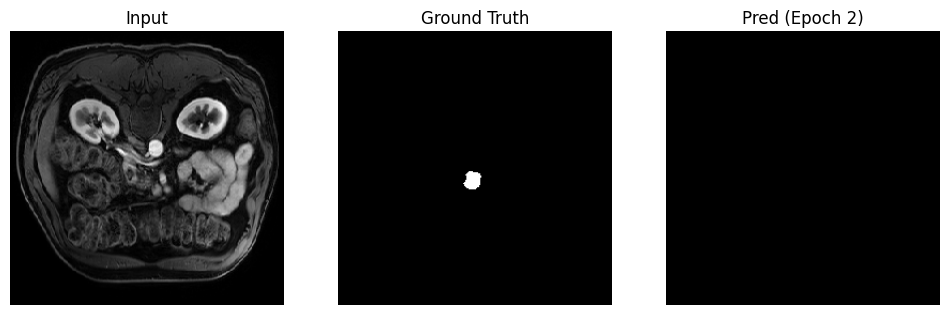

Epoch 3/20:   1%|          | 3/341 [00:03<06:40,  1.18s/it, loss=1.32]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 3/20:  48%|████▊     | 162/341 [03:08<03:27,  1.16s/it, loss=1.31]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Epoch 3/20:  79%|███████▊  | 268/341 [05:11<01:24,  1.16s/it, loss=1.3]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]

Epoch 3/20: Train Loss=1.3052 | Val Loss=1.2987 | Dice=0.3560 | Acc=0.9946 | Prec=0.3752 | Sens=0.8111 | Spec=0.9963 | F1=0.4000 | Time=7.71 min

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


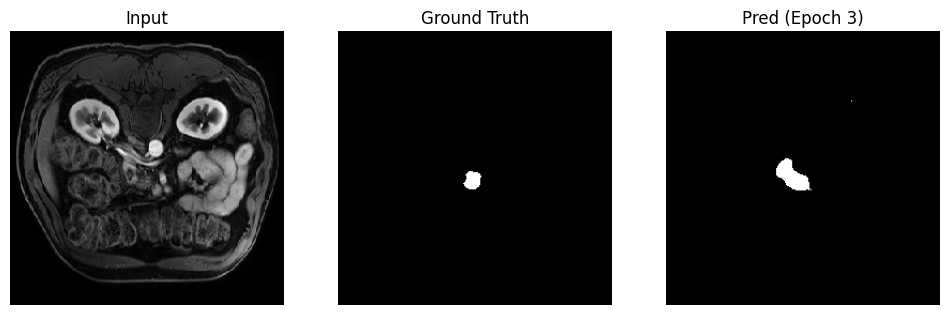

Epoch 4/20:   8%|▊         | 28/341 [00:32<06:04,  1.16s/it, loss=1.29]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Epoch 4/20:  21%|██        | 70/341 [01:21<05:14,  1.16s/it, loss=1.29]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 4/20:  56%|█████▋    | 192/341 [03:43<02:53,  1.16s/it, loss=1.28]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]

Epoch 4/20: Train Loss=1.2795 | Val Loss=1.2685 | Dice=0.6295 | Acc=0.9971 | Prec=0.7394 | Sens=0.7815 | Spec=0.9991 | F1=0.6512 | Time=7.74 min

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


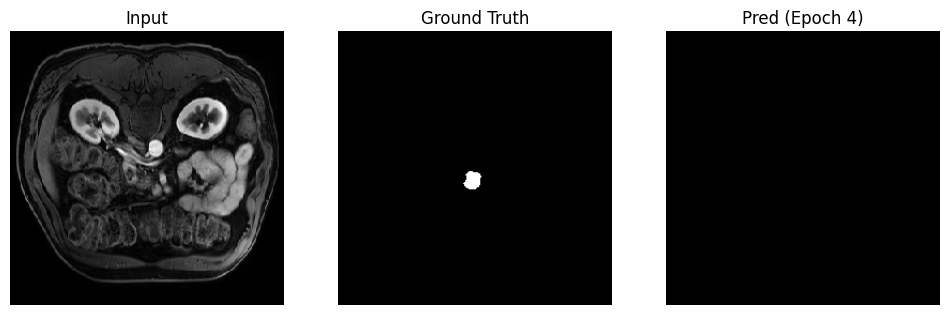

Epoch 5/20:  40%|████      | 137/341 [02:39<03:56,  1.16s/it, loss=1.25]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Epoch 5/20:  55%|█████▍    | 187/341 [03:38<02:59,  1.16s/it, loss=1.26]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 5/20:  57%|█████▋    | 196/341 [03:48<02:49,  1.17s/it, loss=1.26]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]

Epoch 5/20: Train Loss=1.2555 | Val Loss=1.2464 | Dice=0.6072 | Acc=0.9956 | Prec=0.5772 | Sens=0.9402 | Spec=0.9961 | F1=0.6153 | Time=7.73 min

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


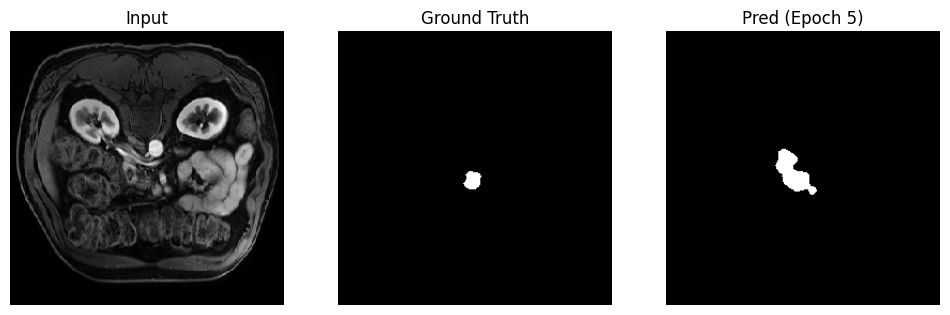

Epoch 6/20:   4%|▎         | 12/341 [00:14<06:24,  1.17s/it, loss=1.25]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 6/20:  57%|█████▋    | 193/341 [03:45<02:51,  1.16s/it, loss=1.24]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Epoch 6/20:  63%|██████▎   | 214/341 [04:09<02:28,  1.17s/it, loss=1.23]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]

Epoch 6/20: Train Loss=1.2347 | Val Loss=1.2252 | Dice=0.7897 | Acc=0.9981 | Prec=0.7959 | Sens=0.9152 | Spec=0.9987 | F1=0.7931 | Time=7.74 min

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]
Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]
Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


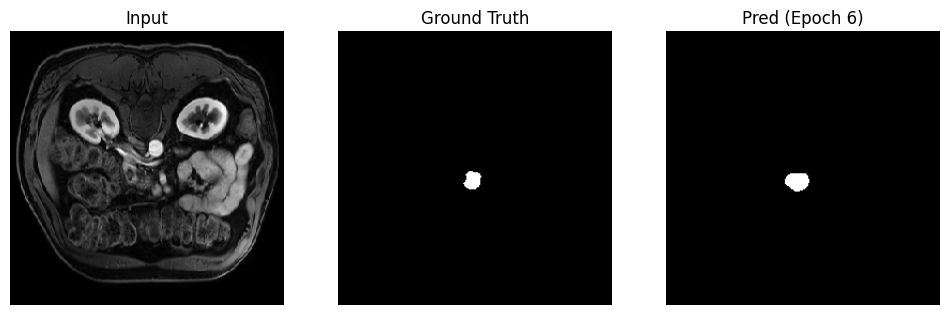

Epoch 7/20:  28%|██▊       | 94/341 [01:49<04:48,  1.17s/it, loss=1.22]

Sample 2: image shape torch.Size([1, 256, 256]), mask unique [0.0, 1.0]


Epoch 7/20:  31%|███▏      | 107/341 [02:04<04:32,  1.16s/it, loss=1.23]

Sample 0: image shape torch.Size([1, 256, 256]), mask unique [0.0]


Epoch 7/20:  56%|█████▋    | 192/341 [03:44<02:52,  1.16s/it, loss=1.2]

Sample 1: image shape torch.Size([1, 256, 256]), mask unique [0.0]


KeyboardInterrupt: 

In [12]:
import torch, torch.nn as nn, time
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import pandas as pd
from google.colab import files

# To store logs
log_data = []

# ✅ Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

# MODEL
model = TransAttUNetPlusPlus(in_channels=1, out_channels=1).to(device)

model_path = "/content/drive/MyDrive/best_TransAttUNetPlusPlusUNet_gpu.pth"

"""
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("✅ Pretrained model loaded successfully!")
else:
    print("⚠ No saved model found. Training will start from scratch.")
"""

criterion_bce = nn.BCEWithLogitsLoss()
criterion_dice = DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr)

#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

scaler = GradScaler()

#epochs = 1
train_losses, val_losses, dice_scores = [], [], []
best_val_dice = -1

# ---------------- Training Loop ---------------- #
for epoch in range(epochs):
    start = time.time()
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device).float()
        optimizer.zero_grad()

        with autocast():
            preds = model(imgs)
            loss = criterion_bce(preds, masks) + criterion_dice(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix({'loss': loss.item()})

    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ----- Validation ----- #
    model.eval()
    val_loss = 0

    dice_total = 0
    acc_total = 0
    prec_total = 0
    rec_total = 0
    sens_total = 0
    spec_total = 0
    f1_total = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device).float()
            preds = model(imgs)

            loss = criterion_bce(preds, masks) + criterion_dice(preds, masks)
            val_loss += loss.item() * imgs.size(0)

            dice_total += dice_metric(preds, masks).item() * imgs.size(0)
            acc_total += accuracy_metric(preds, masks).item() * imgs.size(0)
            prec_total += precision_metric(preds, masks).item() * imgs.size(0)
            sens_total += sensitivity_metric(preds, masks).item() * imgs.size(0)
            spec_total += specificity_metric(preds, masks).item() * imgs.size(0)
            f1_total += f1_score_metric(preds, masks).item() * imgs.size(0)

    # Averages
    N = len(val_loader.dataset)
    val_loss /= N
    dice_epoch = dice_total / N
    acc_epoch = acc_total / N
    prec_epoch = prec_total / N
    sens_epoch = sens_total / N
    spec_epoch = spec_total / N
    f1_epoch = f1_total / N

    val_losses.append(val_loss)
    dice_scores.append(dice_epoch)

    """
    # ✅ UPDATE LR (Cosine Scheduler)
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    """

    print(
        f"\nEpoch {epoch+1}/{epochs}: "
        f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
        f"Dice={dice_epoch:.4f} | Acc={acc_epoch:.4f} | Prec={prec_epoch:.4f} | Sens={sens_epoch:.4f} | Spec={spec_epoch:.4f} | "
        f"F1={f1_epoch:.4f} | Time={(time.time()-start)/60:.2f} min\n"
    )

    log_data.append([
        epoch+1, train_loss, val_loss, dice_epoch,
        acc_epoch, prec_epoch, sens_epoch, spec_epoch, f1_epoch
    ])

    show_sample_prediction(model, val_loader, epoch)

    # Save best model
    if dice_epoch > best_val_dice:
        best_val_dice = dice_epoch
        save_path = "/content/drive/MyDrive/best_TransAttUNetPlusPlusUNet_gpu_bestDice.pth"
        torch.save(model.state_dict(), save_path)

print(f"✅ Model Saved (Best Dice Improved): {best_val_dice:.4f}")

# -----------------------------------------------------------
# SAVE LOG CSV
# -----------------------------------------------------------
df = pd.DataFrame(log_data, columns=[
    "epoch", "train_loss", "val_loss", "dice",
    "accuracy", "precision",
    "sensitivity", "specificity", "f1_score"
])
df.to_csv("training_log_TransAttUNetPlusPlusUNet.csv", index=False)
print("✅ Training log saved to training_log_TransAttUNetPlusPlusUNet.csv")

# files.download("training_log.csv")
